# 13.17 PPO與DPO，為什麼是兩條路？


有了同題兩篇回答的偏好資料，可以先教reward model，再讓policy作答、拿分、用PPO更新；也可以直接用偏好對調整policy，省去獨立評分員，這條路叫**DPO（直接偏好最佳化）**。它仍需要標準與可靠偏好資料。

兩條路從同一示範起點分叉，都保留reference。PPO還學critic與收集新選擇；DPO用13.5的相對log機率差做代價。圖中箭頭分叉，不是先跑PPO才有資格跑DPO。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

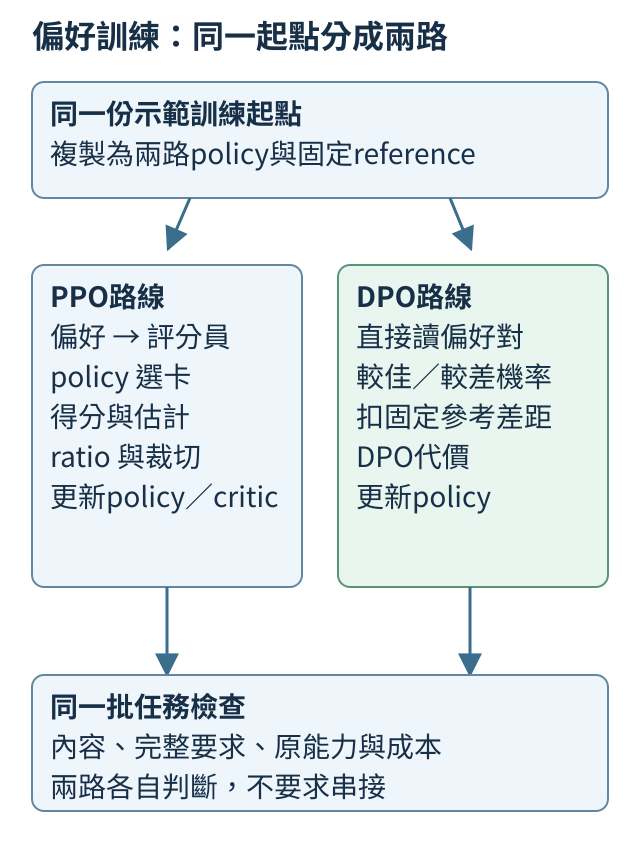

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-13-alternative-routes.svg")))

先用兩張卡核對DPO：第一張標較佳，reference各0.5。當policy也各0.5，相對差距0、代價0.6931；policy改成0.7與0.3時，beta1的代價降為0.3567。


In [3]:
import torch
from tiny_perceptron.alignment import dpo_loss

reference = torch.tensor([0.5, 0.5]).log()
for probabilities in [[0.5, 0.5], [0.7, 0.3]]:
    policy = torch.tensor(probabilities).log()
    loss = dpo_loss(policy[:1], policy[1:], reference[:1], reference[1:], beta=1.0)
    print("較佳／較差機率", probabilities, "偏好代價", round(loss.item(), 4))

較佳／較差機率 [0.5, 0.5] 偏好代價 0.6931
較佳／較差機率 [0.7, 0.3] 偏好代價 0.3567


這是手設機率，沒有評分網路或參數更新。DPO代價下降說明更偏向這份標籤；不保證實際回答滿足全部任務，也不保證和任意PPO實作得到相同模型。

13.16的有限卡比較，兩支都從逐項相同的起點出發，在18題通過12題，但相同步數不等於相同總成本：PPO另需教評分員、更新critic與收集選卡，DPO直接重讀偏好對。這份小任務不足以宣稱哪種方法普遍較好，亦沒有同資料、同預算SFT對照。

若比較標籤來自真人，評分員加PPO可以構成典型**RLHF（人類回饋強化學習）**流程。本章卡片標籤來自作者規則，而且只做單步選擇，不能把它稱爲已完成大型語言模型RLHF或已回灌最後成品。

練習把第二組policy機率改成0.3、0.7，代價約1.2040。它更偏向較差卡；要知道最終用途，仍須實際選擇或生成，並檢查原能力。

<details>
<summary>補充：來源、完整設定與既有實測紀錄</summary>

[DPO原論文第4節公式7](https://arxiv.org/pdf/2305.18290v3)從帶參考約束的偏好目標推導這個方法，不等於「它保證與任何PPO實作得到同一個模型」。真實資料不完美、模型有限、更新配方也不同；兩者都要另外檢查用途。想追完整文字回答的log機率與梯度，可回看[13.3–13.6](https://birdhackor.github.io/tiny-perceptron-vlm/13.3.html)，那條路使用語言模型，與本章的有限選卡實驗分開。

正式CPU比較先保存148參數的示範起點，PPO與DPO兩支從逐項相同的權重開始；偏好都來自同一批訓練家族。這裡的家族把使用相同兩個加數的題目放在一起，不因交換加數或改變回答要求就拆開，例如1加2與2加1屬於同一家族；兩路都只使用分在訓練組的44個家族。PPO做360次策略更新，DPO也做360次、每批64對，共抽用23,040對。兩者都在最後18題通過12題，且[13.16](https://birdhackor.github.io/tiny-perceptron-vlm/13.16.html)列出的分項相同：數字與求補資訊成功，句子要求仍未學好。但同樣更新360次，不等於同樣計算或資料預算：PPO另有300次評分員更新、360次critic更新、7,680次真實取樣；DPO直接重讀偏好對。

這次PPO段約0.66秒，DPO段約0.34秒；評分員另花約0.27秒，都是本機CPU小網路的段落時間，不是大型LLM效能結論。偏好資料含示範階段沒教的條件，因此也不能說PPO或DPO勝過同資料、同預算的SFT。表格支持「這個固定配方新增了求補資訊的選擇，仍沒完成全部要求」，不支持哪種方法普遍比較好。

</details>
